In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install open_clip_torch timm scikit-learn matplotlib seaborn pandas -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, io, json, pickle, random, shutil, itertools
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from PIL import Image
import open_clip
import timm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

RUN_518_PROBE = True     # set False to skip the slow native-resolution probe
RUN_LEGACY_20 = True     # set False to skip the legacy 20-class reference run

Device: cuda


In [ ]:
PROJECT_DIR  = Path('/content/drive/MyDrive/Indian_Food_Research')
DATASET_PATH = PROJECT_DIR / 'datasets' / 'CompressedDataset'
FOOD101_ROOT = PROJECT_DIR / 'datasets' / 'Food101'
SPLITS_DIR   = PROJECT_DIR / 'splits'
RESULTS_DIR  = PROJECT_DIR / 'results'
FIGURES_DIR  = PROJECT_DIR / 'figures'
REPORTS_DIR  = PROJECT_DIR / 'reports'
for d in (RESULTS_DIR, FIGURES_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

In [ ]:
LOCAL_DS = DATASET_PATH

In [ ]:
indian_full        = datasets.ImageFolder(str(LOCAL_DS))
indian_class_names = indian_full.classes
NUM_CLASSES        = len(indian_class_names)

print(f'Indian benchmark: {len(indian_full.samples)} images | {NUM_CLASSES} classes')
assert NUM_CLASSES == 100, f'Expected 100 classes, got {NUM_CLASSES} — Drive may be mid-sync. STOP.'
assert len(indian_full.samples) == 4578, f'Expected 4578 images, got {len(indian_full.samples)}. STOP.'

train_idx = pickle.load(open(SPLITS_DIR / 'train_idx.pkl', 'rb'))
val_idx   = pickle.load(open(SPLITS_DIR / 'val_idx.pkl',   'rb'))
test_idx  = pickle.load(open(SPLITS_DIR / 'test_idx.pkl',  'rb'))

assert not (set(train_idx) & set(test_idx)), 'train/test overlap'
assert not (set(val_idx)   & set(test_idx)), 'val/test overlap'
assert max(max(train_idx), max(val_idx), max(test_idx)) < len(indian_full.samples)
print(f'Splits: train {len(train_idx)} | val {len(val_idx)} | test {len(test_idx)}  — guards passed')

# Class-name file written by notebook 01, used for the confusion-matrix axes.
class_csv = REPORTS_DIR / 'class_names.csv'
if class_csv.exists():
    csv_names = pd.read_csv(class_csv)['Class'].tolist()
    assert csv_names == indian_class_names, 'class_names.csv disagrees with ImageFolder ordering. STOP.'
    print('class_names.csv ordering verified against ImageFolder.')
class_names = indian_class_names

Indian benchmark: 4578 images | 100 classes
Splits: train 3204 | val 687 | test 687  — guards passed
class_names.csv ordering verified against ImageFolder.


In [ ]:
le_csv = RESULTS_DIR / 'label_efficiency_results.csv'
if le_csv.exists():
    le = pd.read_csv(le_csv)
    row = le[(le['method'] == 'resnet50_scratch') & (le['fraction'] == 1.0)]
    RESNET_SCRATCH_ACC = float(row['test_acc'].iloc[0])
    print(f'ResNet-50 (scratch), from label_efficiency_results.csv: {RESNET_SCRATCH_ACC*100:.2f}%')
else:
    RESNET_SCRATCH_ACC = None
    print('label_efficiency_results.csv not found — run notebook 03 first; '
          'do NOT reinstate the hardcoded 0.5793.')

ResNet-50 (scratch), from label_efficiency_results.csv: 59.24%


In [ ]:
candidates = [FOOD101_ROOT / 'food-101' / 'images', FOOD101_ROOT / 'images', FOOD101_ROOT]
FOOD101_IMAGES = None
for c in candidates:
    if c.is_dir():
        n_sub = len([p for p in c.iterdir() if p.is_dir()])
        print(f'{c}  ->  {n_sub} sub-directories')
        if n_sub > 50:
            FOOD101_IMAGES = c
            break

assert FOOD101_IMAGES is not None, (
    'Food-101 image root not found. Expected <root>/food-101/images with 101 class folders. '
    'Re-download: torchvision.datasets.Food101(root=FOOD101_ROOT, split="test", download=True)')

META_DIR = FOOD101_IMAGES.parent / 'meta'
western_all = datasets.ImageFolder(str(FOOD101_IMAGES))
print(f'\nFood-101: {len(western_all.classes)} classes | {len(western_all.samples)} images')
assert len(western_all.classes) == 101, (
    f'GUARD FAILED: {len(western_all.classes)} classes, expected 101. '
    'This is the Section VI-A defect. Report nothing from this run.')
print('Guard passed — the directory-structure defect is not present.')

/content/drive/MyDrive/Indian_Food_Research/datasets/Food101/food-101/images  ->  101 sub-directories

Food-101: 101 classes | 101000 images
Guard passed — the directory-structure defect is not present.


In [ ]:
test_json = META_DIR / 'test.json'
if test_json.exists():
    meta = json.loads(test_json.read_text())
    official_test = {cls: [FOOD101_IMAGES / f'{rel}.jpg' for rel in rels] for cls, rels in meta.items()}
    print(f'Official test split: {sum(len(v) for v in official_test.values())} images '
          f'across {len(official_test)} classes')
else:
    print('meta/test.json missing — falling back to a seeded 25% per-class holdout.')
    official_test, rng = {}, random.Random(SEED)
    for cls in western_all.classes:
        files = sorted((FOOD101_IMAGES / cls).glob('*.jpg'))
        rng.shuffle(files)
        official_test[cls] = files[: max(1, len(files) // 4)]

western_pool = sorted(official_test.keys())

Official test split: 25250 images across 101 classes


In [ ]:
indian_test_counts = Counter(indian_full.targets[i] for i in test_idx)
count_profile = sorted((indian_test_counts[c] for c in range(NUM_CLASSES)), reverse=True)
print(f'Indian test: {sum(count_profile)} images | per-class min {min(count_profile)} '
      f'max {max(count_profile)} median {int(np.median(count_profile))}')

rng = random.Random(SEED)
chosen = sorted(rng.sample(western_pool, 100))

western_items = []
for cls, n_wanted in zip(chosen, count_profile):
    files = sorted(official_test[cls])
    rng.shuffle(files)
    western_items += [(p, chosen.index(cls)) for p in files[: min(n_wanted, len(files))]]

print(f'Matched Western test: {len(western_items)} images | {len(chosen)} classes')
assert len(western_items) == len(test_idx), 'Matched set size differs from the Indian test set.'
assert len(set(l for _, l in western_items)) == 100, 'A Western class ended up empty.'
print('Both sides: 100-way, 687 images, identical per-class count profile.')

Indian test: 687 images | per-class min 1 max 13 median 7
Matched Western test: 687 images | 100 classes
Both sides: 100-way, 687 images, identical per-class count profile.


In [ ]:
class PathListDataset(Dataset):
    """Western set: explicit (path, label) pairs — no index arithmetic against a foreign dataset."""
    def __init__(self, items, transform):
        self.items, self.transform = items, transform
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        path, label = self.items[i]
        return self.transform(Image.open(path).convert('RGB')), label


class IndexedDataset(Dataset):
    """Indian set: indices into the ImageFolder they were generated from."""
    def __init__(self, base, indices, transform):
        self.base, self.indices, self.transform = base, indices, transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        return self.transform(Image.open(path).convert('RGB')), label

In [ ]:
indian_templates = [
    'a photo of {}, an Indian dish',
    'a close-up photo of {} served on a plate',
    'a restaurant photo of Indian food: {}',
]
western_templates = [
    'a photo of {}, a food dish',
    'a restaurant photo of {}',
    'a close-up photo of {}',
]


def encode_prompts(names, templates, model, tokenizer):
    feats = []
    for tmpl in templates:
        tokens = tokenizer([tmpl.format(c.replace('_', ' ')) for c in names]).to(device)
        with torch.no_grad():
            tf = model.encode_text(tokens)
            tf = tf / tf.norm(dim=-1, keepdim=True)
        feats.append(tf)
    out = torch.stack(feats).mean(0)
    return out / out.norm(dim=-1, keepdim=True)      # re-normalise after averaging


@torch.no_grad()
def run_zero_shot(loader, text_features, model):
    preds, labels = [], []
    model.eval()
    for imgs, lbs in loader:
        f = model.encode_image(imgs.to(device))
        f = f / f.norm(dim=-1, keepdim=True)
        preds.extend((f @ text_features.T).argmax(1).cpu().numpy())
        labels.extend(lbs.numpy())
    return np.array(labels), np.array(preds)


@torch.no_grad()
def extract_features(loader, model):
    F, Y = [], []
    model.eval()
    for imgs, lbs in loader:
        F.append(model(imgs.to(device)).cpu().numpy())
        Y.append(lbs.numpy())
    return np.concatenate(F), np.concatenate(Y)


def wilson(k, n, z=1.96):
    ph = k / n
    d = 1 + z ** 2 / n
    c = ph + z ** 2 / (2 * n)
    half = z * np.sqrt(ph * (1 - ph) / n + z ** 2 / (4 * n ** 2))
    return 100 * (c - half) / d, 100 * (c + half) / d


def gap_ci(corr_west, corr_ind, n_boot=10000, alpha=0.05):
    cw, ci_ = np.asarray(corr_west, float), np.asarray(corr_ind, float)
    rs = np.random.RandomState(SEED)
    gaps = np.empty(n_boot)
    for b in range(n_boot):
        gaps[b] = (cw[rs.randint(0, len(cw), len(cw))].mean()
                   - ci_[rs.randint(0, len(ci_), len(ci_))].mean())
    return (100 * np.percentile(gaps, 100 * alpha / 2),
            100 * np.percentile(gaps, 100 * (1 - alpha / 2)))


def save_fig(name):
    for ext in ('png', 'pdf'):
        plt.savefig(FIGURES_DIR / f'{name}.{ext}', dpi=300, bbox_inches='tight')
    print('Saved ->', FIGURES_DIR / f'{name}.png')

In [ ]:
MODELS = [
    ('CLIP ViT-B/32', 'ViT-B-32',             'laion2b_s34b_b79k', 64),
    ('CLIP ViT-L/14', 'ViT-L-14',             'laion2b_s32b_b82k', 32),
    ('SigLIP SO400M', 'ViT-SO400M-14-SigLIP', 'webli',             32),
]

CKPT = RESULTS_DIR / 'zeroshot_fixed_checkpoints.json'
records = json.loads(CKPT.read_text()) if CKPT.exists() else []
done = {r['model'] for r in records}
print('Already done:', done or '(none)')

zs_preds = {}
for disp, arch, pretrained, bs in MODELS:
    if disp in done:
        print('SKIP', disp)
        continue
    print(f'\n=== {disp} ===')
    model, _, preprocess = open_clip.create_model_and_transforms(arch, pretrained=pretrained)
    tokenizer = open_clip.get_tokenizer(arch)
    model = model.to(device).eval()

    ind_loader = DataLoader(IndexedDataset(indian_full, test_idx, preprocess),
                            batch_size=bs, shuffle=False, num_workers=2)
    wes_loader = DataLoader(PathListDataset(western_items, preprocess),
                            batch_size=bs, shuffle=False, num_workers=2)

    y_ind, p_ind = run_zero_shot(ind_loader, encode_prompts(indian_class_names, indian_templates,
                                                            model, tokenizer), model)
    y_wes, p_wes = run_zero_shot(wes_loader, encode_prompts(chosen, western_templates,
                                                            model, tokenizer), model)

    c_ind, c_wes = (y_ind == p_ind).astype(int), (y_wes == p_wes).astype(int)
    acc_i, acc_w = 100 * c_ind.mean(), 100 * c_wes.mean()
    lo_i, hi_i = wilson(int(c_ind.sum()), len(c_ind))
    lo_w, hi_w = wilson(int(c_wes.sum()), len(c_wes))
    lo_g, hi_g = gap_ci(c_wes, c_ind)

    print(f'  Indian  : {acc_i:6.2f}%  [{lo_i:.2f}, {hi_i:.2f}]')
    print(f'  Western : {acc_w:6.2f}%  [{lo_w:.2f}, {hi_w:.2f}]')
    print(f'  Gap     : {acc_w - acc_i:+6.2f} pp [{lo_g:.2f}, {hi_g:.2f}]')

    records.append({'model': disp,
                    'indian_acc': acc_i, 'indian_ci': [lo_i, hi_i],
                    'western_acc': acc_w, 'western_ci': [lo_w, hi_w],
                    'gap_pp': acc_w - acc_i, 'gap_ci': [lo_g, hi_g],
                    'n': int(len(c_ind)), 'n_classes': 100})
    CKPT.write_text(json.dumps(records, indent=2))

    tag = disp.replace('/', '').replace(' ', '_')
    np.save(RESULTS_DIR / f'preds_indian_{tag}.npy', np.vstack([y_ind, p_ind]))
    np.save(RESULTS_DIR / f'preds_western_{tag}.npy', np.vstack([y_wes, p_wes]))
    zs_preds[disp] = (y_ind, p_ind)

    del model
    torch.cuda.empty_cache()

print('\nAll zero-shot runs complete.')

Already done: (none)

=== CLIP ViT-B/32 ===


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

  Indian  :  40.47%  [36.86, 44.18]
  Western :  82.39%  [79.36, 85.05]
  Gap     : +41.92 pp [37.41, 46.58]

=== CLIP ViT-L/14 ===


open_clip_pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.71GB            

...

open_clip_model.safetensors: downloading bytes:           |  0.00B            

tokenizer_config.json:   0%|          | 0.00/20.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

  Indian  :  74.38%  [70.99, 77.50]
  Western :  95.92%  [94.17, 97.17]
  Gap     : +21.54 pp [18.05, 25.18]

All zero-shot runs complete.


In [ ]:
table5 = pd.DataFrame([{
    'Model': r['model'],
    'Indian Top-1 (%)':  f"{r['indian_acc']:.2f} [{r['indian_ci'][0]:.1f}, {r['indian_ci'][1]:.1f}]",
    'Western Top-1 (%)': f"{r['western_acc']:.2f} [{r['western_ci'][0]:.1f}, {r['western_ci'][1]:.1f}]",
    'Gap (pp)':          f"{r['gap_pp']:.2f} [{r['gap_ci'][0]:.1f}, {r['gap_ci'][1]:.1f}]",
} for r in records])

table5.to_csv(RESULTS_DIR / 'table5_cultural_gap_FIXED.csv', index=False)
print(table5.to_string(index=False))
print('\nProtocol: both sides 100-way, 687 images, matched per-class counts, Food-101 official '
      'test split, 3 averaged prompt templates, 95% Wilson CIs (gap CI by bootstrap).')

        Model   Indian Top-1 (%)  Western Top-1 (%)           Gap (pp)
CLIP ViT-B/32 40.47 [36.9, 44.2] 82.39 [79.4, 85.1] 41.92 [37.4, 46.6]
CLIP ViT-L/14 46.14 [42.4, 49.9] 90.54 [88.1, 92.5] 44.40 [40.0, 48.8]
SigLIP SO400M 74.38 [71.0, 77.5] 95.92 [94.2, 97.2] 21.54 [18.0, 25.2]

Protocol: both sides 100-way, 687 images, matched per-class counts, Food-101 official test split, 3 averaged prompt templates, 95% Wilson CIs (gap CI by bootstrap).


Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig6_cultural_gap_FIXED.png


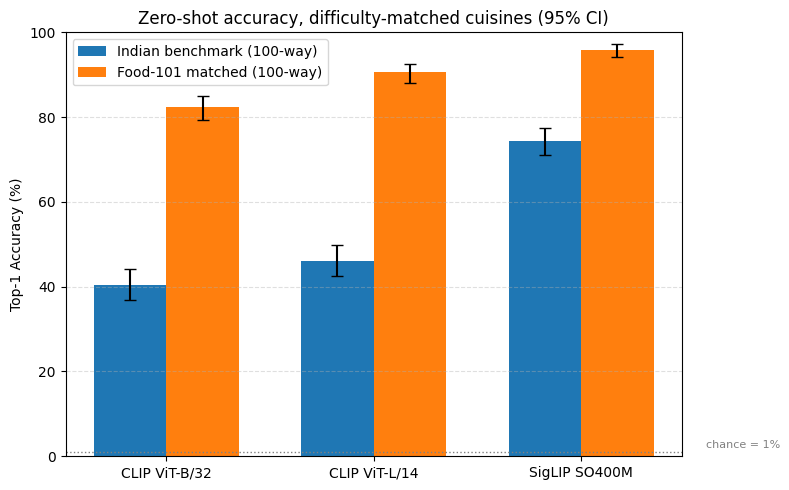

In [ ]:
labels = [r['model'] for r in records]
ind = [r['indian_acc'] for r in records]
wes = [r['western_acc'] for r in records]
ind_err = np.array([[r['indian_acc'] - r['indian_ci'][0] for r in records],
                    [r['indian_ci'][1] - r['indian_acc'] for r in records]])
wes_err = np.array([[r['western_acc'] - r['western_ci'][0] for r in records],
                    [r['western_ci'][1] - r['western_acc'] for r in records]])

x, w = np.arange(len(labels)), 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - w / 2, ind, w, yerr=ind_err, capsize=4, label='Indian benchmark (100-way)')
plt.bar(x + w / 2, wes, w, yerr=wes_err, capsize=4, label='Food-101 matched (100-way)')
plt.axhline(1.0, ls=':', lw=1, color='grey')
plt.text(len(labels) - 0.4, 2.0, 'chance = 1%', fontsize=8, color='grey')
plt.xticks(x, labels)
plt.ylabel('Top-1 Accuracy (%)')
plt.ylim(0, 100)
plt.title('Zero-shot accuracy, difficulty-matched cuisines (95% CI)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
save_fig('fig6_cultural_gap_FIXED')
plt.show()

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig6b_cultural_gap_bars_FIXED.png


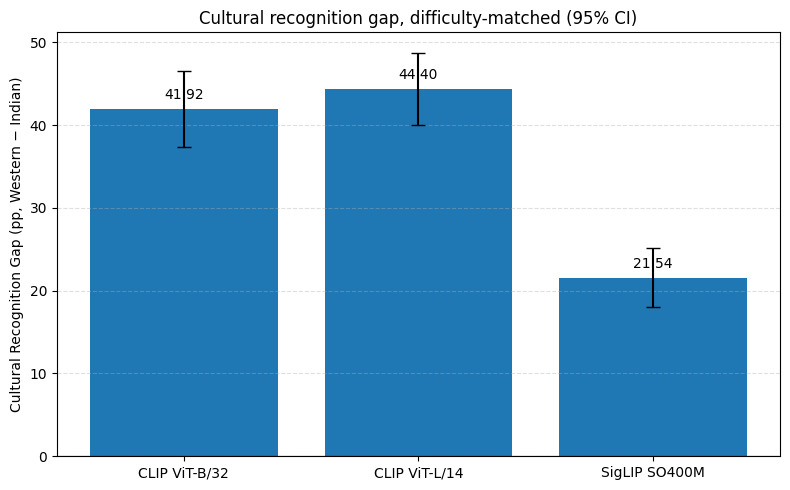

In [ ]:
plt.figure(figsize=(8, 5))
gaps = [r['gap_pp'] for r in records]
err = np.array([[r['gap_pp'] - r['gap_ci'][0] for r in records],
                [r['gap_ci'][1] - r['gap_pp'] for r in records]])
bars = plt.bar(labels, gaps, yerr=err, capsize=5)
for b, g in zip(bars, gaps):
    plt.text(b.get_x() + b.get_width() / 2, g + 1.2, f'{g:.2f}', ha='center', fontsize=10)
plt.axhline(0, color='black', lw=0.8)
plt.ylabel('Cultural Recognition Gap (pp, Western − Indian)')
plt.title('Cultural recognition gap, difficulty-matched (95% CI)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
save_fig('fig6b_cultural_gap_bars_FIXED')
plt.show()

In [ ]:
if RUN_LEGACY_20:
    legacy_20 = ['apple_pie', 'beef_carpaccio', 'beef_tartare', 'caesar_salad', 'cheesecake',
                 'club_sandwich', 'french_fries', 'fried_calamari', 'grilled_salmon', 'hamburger',
                 'hot_dog', 'ice_cream', 'lasagna', 'macaroni_and_cheese', 'omelette', 'pizza',
                 'ravioli', 'spaghetti_bolognese', 'steak', 'waffles']
    missing = [c for c in legacy_20 if c not in official_test]
    assert not missing, f'Not in Food-101 test meta: {missing}'

    rng20 = random.Random(SEED)
    legacy_items = []
    for i, cls in enumerate(legacy_20):
        files = sorted(official_test[cls])
        rng20.shuffle(files)
        legacy_items += [(p, i) for p in files[:113]]
    print(f'Legacy set: {len(legacy_items)} images | {len(legacy_20)} classes')

    m, _, prep = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
    tok = open_clip.get_tokenizer('ViT-B-32')
    m = m.to(device).eval()
    y, p = run_zero_shot(DataLoader(PathListDataset(legacy_items, prep), batch_size=64, num_workers=2),
                         encode_prompts(legacy_20, western_templates, m, tok), m)
    acc = 100 * (y == p).mean()
    lo, hi = wilson(int((y == p).sum()), len(y))
    print(f'\nCLIP ViT-B/32, legacy 20-class Western set: {acc:.2f}% [{lo:.2f}, {hi:.2f}]')
    print('Chance 5% here vs 1% on the 100-way Indian set — NOT a valid comparison. Reference only.')
    del m
    torch.cuda.empty_cache()
else:
    print('Skipped (RUN_LEGACY_20 = False)')

Legacy set: 2260 images | 20 classes

CLIP ViT-B/32, legacy 20-class Western set: 92.48% [91.32, 93.49]
Chance 5% here vs 1% on the 100-way Indian set — NOT a valid comparison. Reference only.


In [ ]:
dino518 = dino
print('DINOv2 native input size from pretrained_cfg:', native_cfg['input_size'])

# Separate instance with the patch grid resized to 224
dino224 = timm.create_model('vit_base_patch14_dinov2', pretrained=True,
                            num_classes=0, img_size=224).to(device).eval()

probe_rows = {}

tf224 = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
Xtr, ytr = extract_features(DataLoader(IndexedDataset(indian_full, train_idx, tf224),
                                       batch_size=64, num_workers=2), dino224)
Xte, yte = extract_features(DataLoader(IndexedDataset(indian_full, test_idx, tf224),
                                       batch_size=64, num_workers=2), dino224)
clf224 = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED).fit(Xtr, ytr)
p224 = clf224.predict(Xte)
k = int((p224 == yte).sum()); lo, hi = wilson(k, len(yte))
probe_rows['logreg @ 224'] = (100 * k / len(yte), lo, hi)
print(f'\nLogistic-regression probe @ 224: {100*k/len(yte):.2f}%  [{lo:.2f}, {hi:.2f}]')
np.save(RESULTS_DIR / 'preds_probe_logreg_224.npy', np.vstack([yte, p224]))

del dino224
torch.cuda.empty_cache()

DINOv2 native input size from pretrained_cfg: (3, 518, 518)

Logistic-regression probe @ 224: 95.05%  [93.16, 96.44]


In [ ]:
# --- 518x518: DINOv2's native resolution, what the original notebook actually ran ---
if RUN_518_PROBE:
    tf518 = timm.data.create_transform(**native_cfg)
    Xtr5, ytr5 = extract_features(DataLoader(IndexedDataset(indian_full, train_idx, tf518),
                                             batch_size=16, num_workers=2), dino)
    Xte5, yte5 = extract_features(DataLoader(IndexedDataset(indian_full, test_idx, tf518),
                                             batch_size=16, num_workers=2), dino)
    clf518 = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED).fit(Xtr5, ytr5)
    p518 = clf518.predict(Xte5)
    k = int((p518 == yte5).sum()); lo, hi = wilson(k, len(yte5))
    probe_rows['logreg @ 518 (native)'] = (100 * k / len(yte5), lo, hi)
    print(f'Logistic-regression probe @ 518: {100*k/len(yte5):.2f}%  [{lo:.2f}, {hi:.2f}]')
    np.save(RESULTS_DIR / 'preds_probe_logreg_518.npy', np.vstack([yte5, p518]))
else:
    print('Skipped (RUN_518_PROBE = False)')

del dino
torch.cuda.empty_cache()

Logistic-regression probe @ 518: 96.07%  [94.34, 97.29]


In [ ]:
probe_df = pd.DataFrame([{'Probe': k, 'Top-1 (%)': round(v[0], 2),
                          '95% CI': f'[{v[1]:.2f}, {v[2]:.2f}]'} for k, v in probe_rows.items()])
probe_df.to_csv(RESULTS_DIR / 'linear_probe_resolution_comparison.csv', index=False)
print(probe_df.to_string(index=False))

                Probe  Top-1 (%)         95% CI
         logreg @ 224      95.05 [93.16, 96.44]
logreg @ 518 (native)      96.07 [94.34, 97.29]


CLIP ViT-B/32 Indian accuracy: 40.47%
Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9_confusion_matrix_clip_b32.png


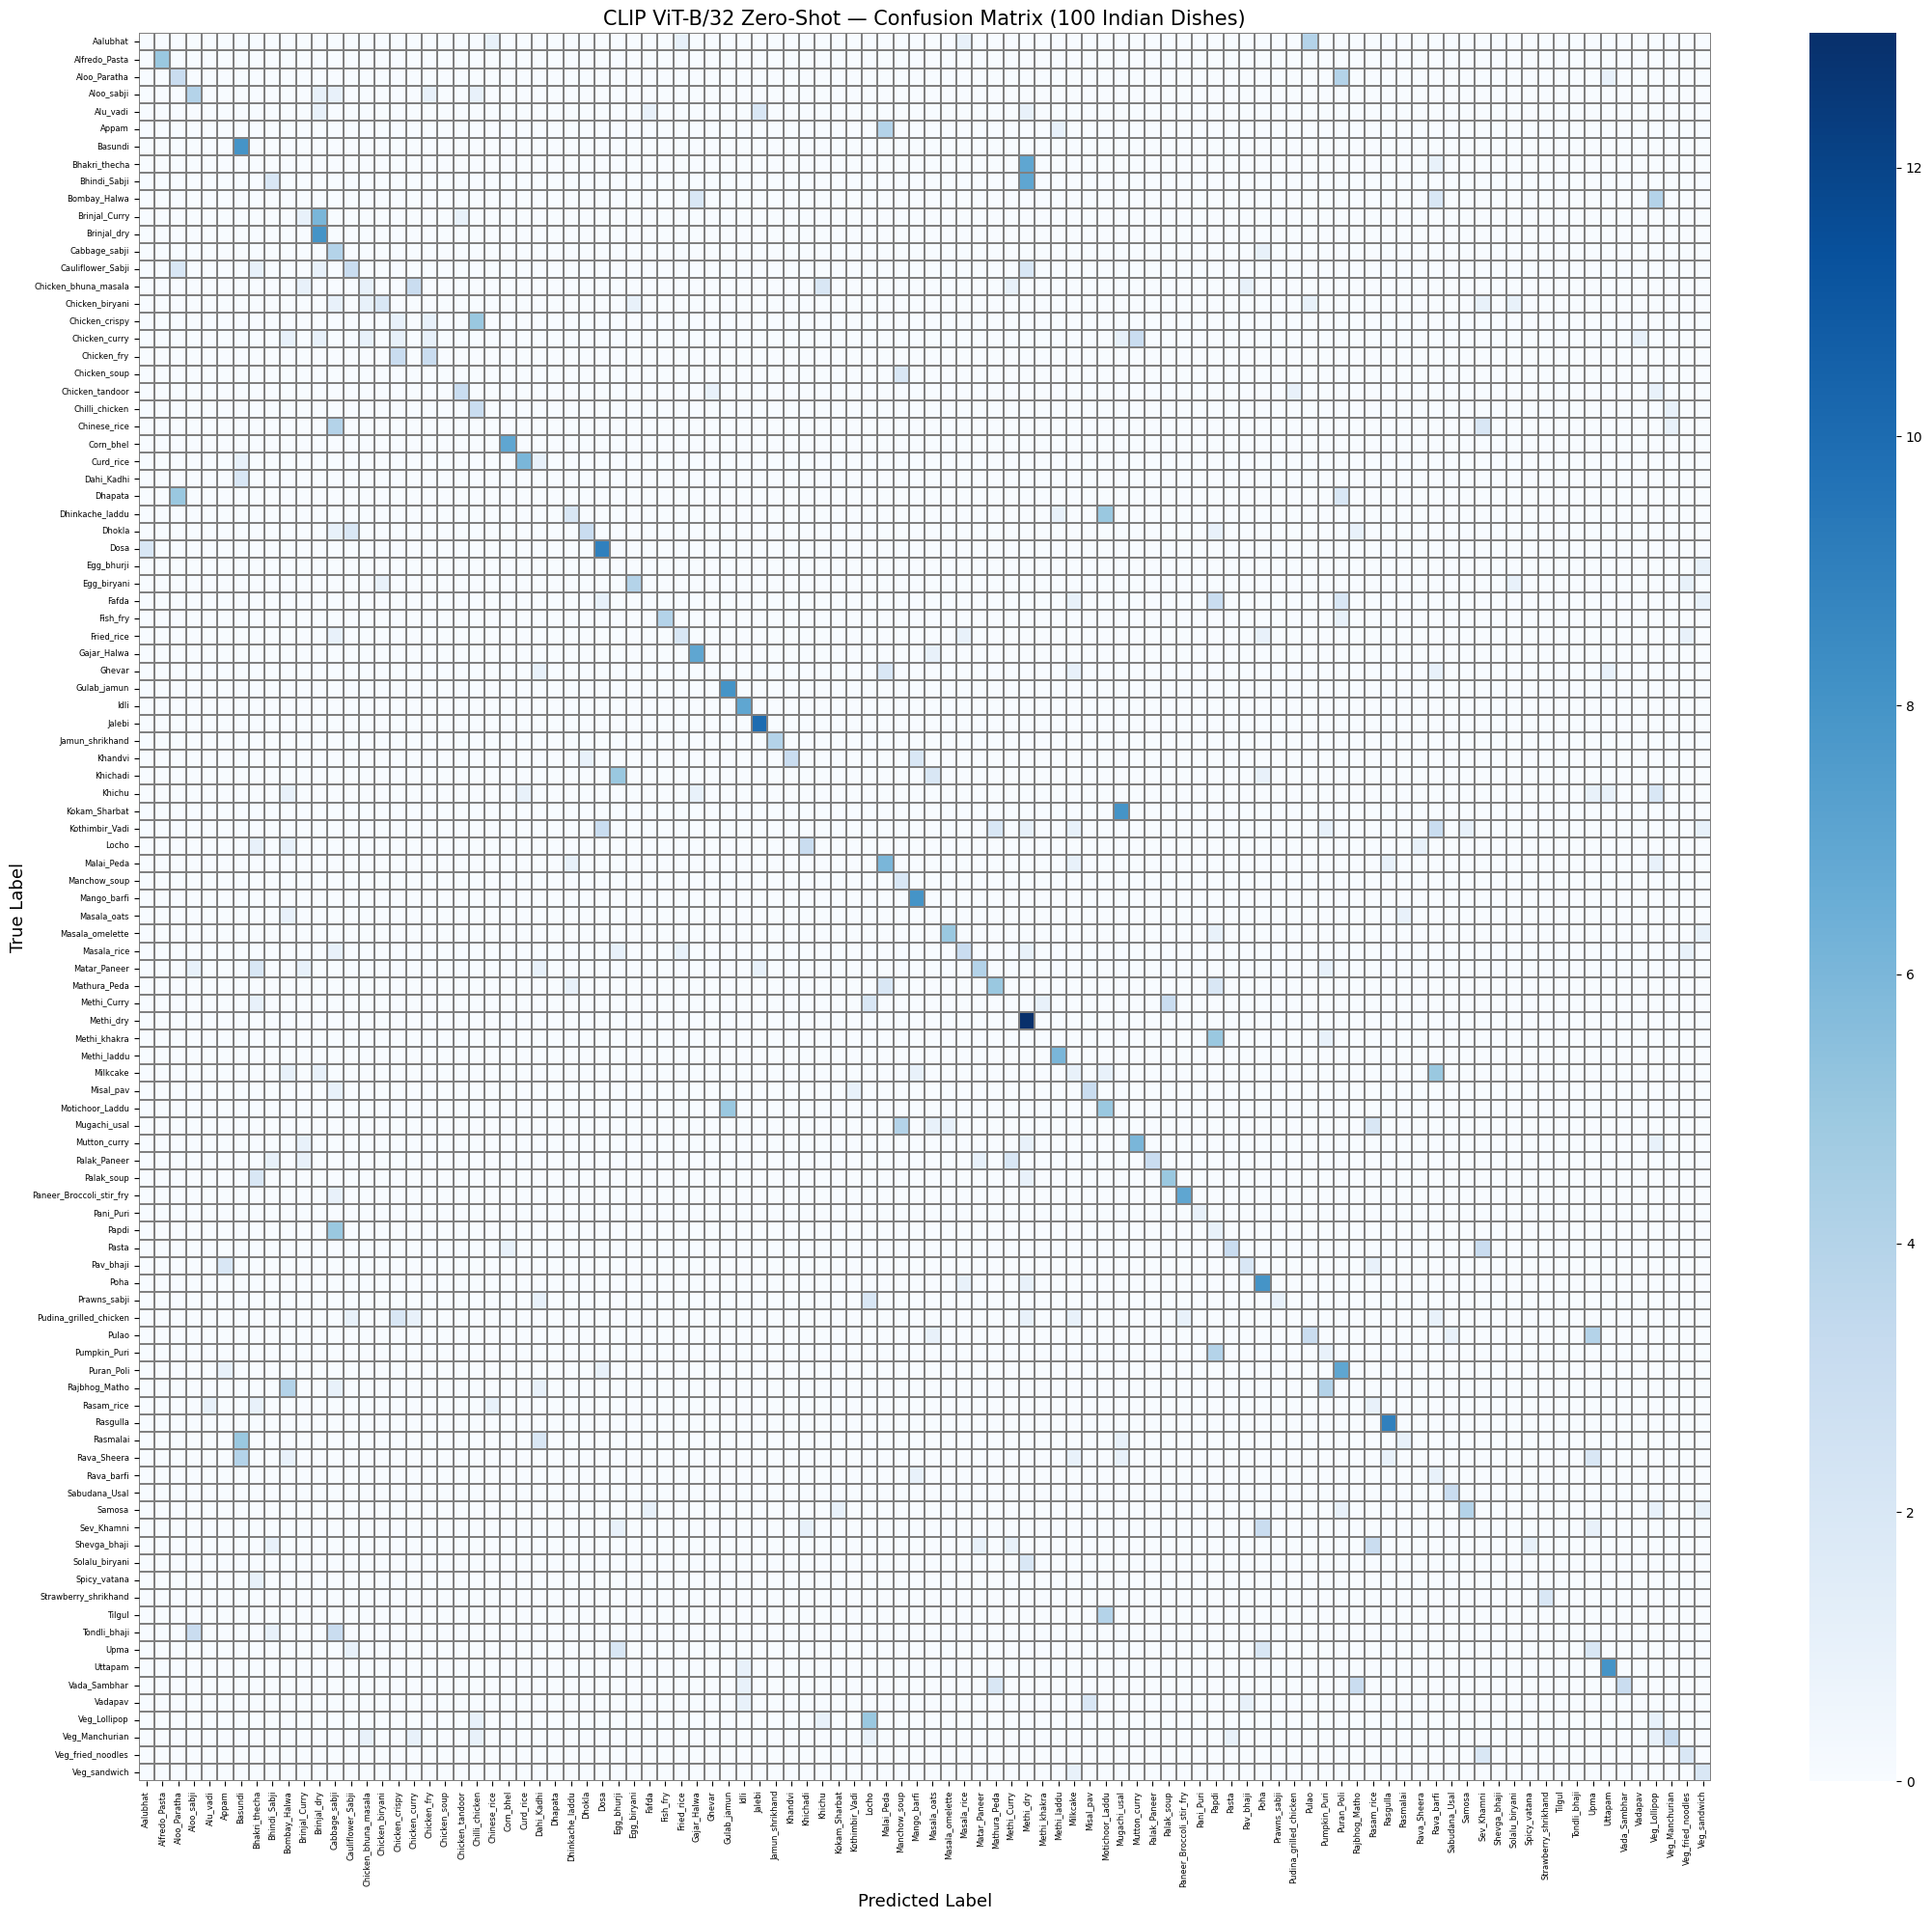

In [ ]:
tag = 'CLIP_ViT-B32'
arr = np.load(RESULTS_DIR / f'preds_indian_{tag}.npy')
labels_b32, preds_b32 = arr[0], arr[1]
print(f'CLIP ViT-B/32 Indian accuracy: {100*(labels_b32 == preds_b32).mean():.2f}%')

cm = confusion_matrix(labels_b32, preds_b32)
fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(cm, annot=False, xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=ax, linewidths=0.3, linecolor='gray')
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('CLIP ViT-B/32 Zero-Shot — Confusion Matrix (100 Indian Dishes)', fontsize=15)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
save_fig('fig9_confusion_matrix_clip_b32')
plt.show()

In [ ]:
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat = np.argsort(cm_off.ravel())[::-1][:20]
rows_i, cols_i = np.unravel_index(flat, cm_off.shape)

confused_pairs = pd.DataFrame({
    'True Class':      [class_names[r] for r in rows_i],
    'Predicted Class': [class_names[c] for c in cols_i],
    'Count':           [int(cm_off[r, c]) for r, c in zip(rows_i, cols_i)],
}).head(10).reset_index(drop=True)

confused_pairs.to_csv(RESULTS_DIR / 'table8_confusion_pairs_FIXED.csv', index=False)
print(confused_pairs.to_string(index=False))
print('\nSanity note: class_names came from the same sorted ImageFolder ordering used at inference '
      '(asserted in cell 1), so these are genuine CLIP errors, not label misalignment.')

     True Class Predicted Class  Count
  Kokam_Sharbat    Mugachi_usal      8
  Bhakri_thecha       Methi_dry      7
   Bhindi_Sabji       Methi_dry      7
  Brinjal_Curry     Brinjal_dry      6
Dhinkache_laddu Motichoor_Laddu      5
          Papdi   Cabbage_sabji      5
        Dhapata    Aloo_Paratha      5
       Khichadi      Egg_bhurji      5
       Rasmalai         Basundi      5
   Methi_khakra           Papdi      5

Sanity note: class_names came from the same sorted ImageFolder ordering used at inference (asserted in cell 1), so these are genuine CLIP errors, not label misalignment.


Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9b_failure_Kokam_Sharbat_as_Mugachi_usal.png


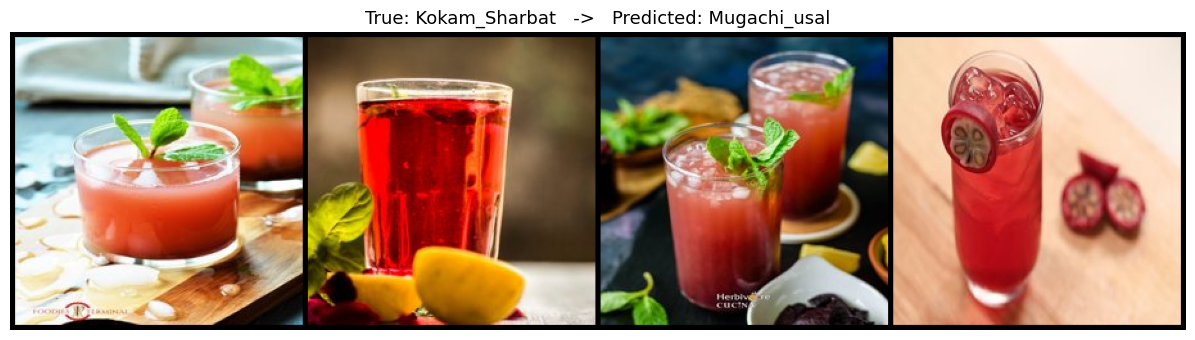

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9b_failure_Bhakri_thecha_as_Methi_dry.png


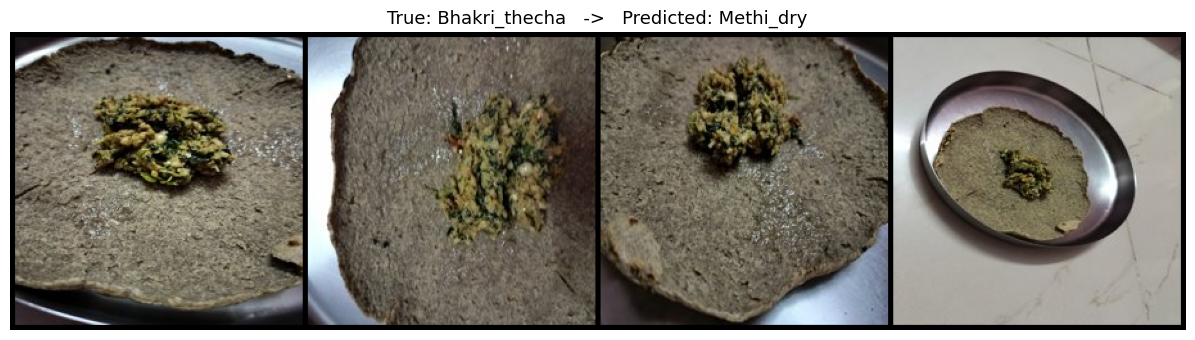

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9b_failure_Bhindi_Sabji_as_Methi_dry.png


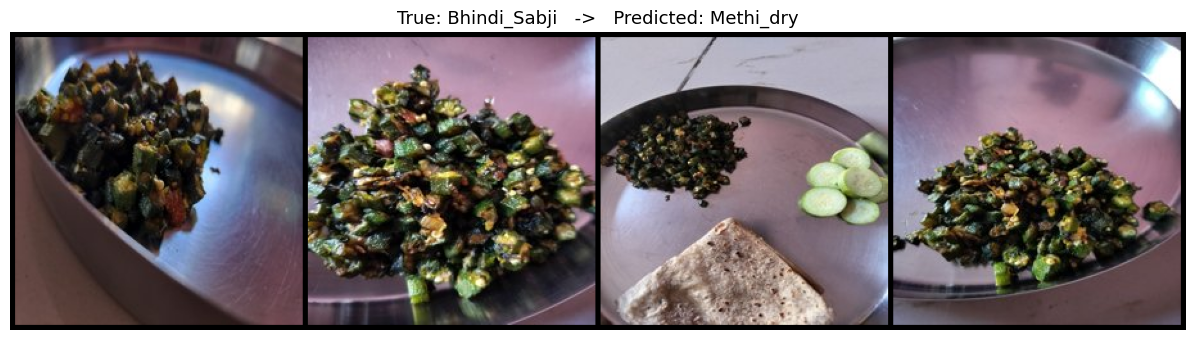

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9b_failure_Brinjal_Curry_as_Brinjal_dry.png


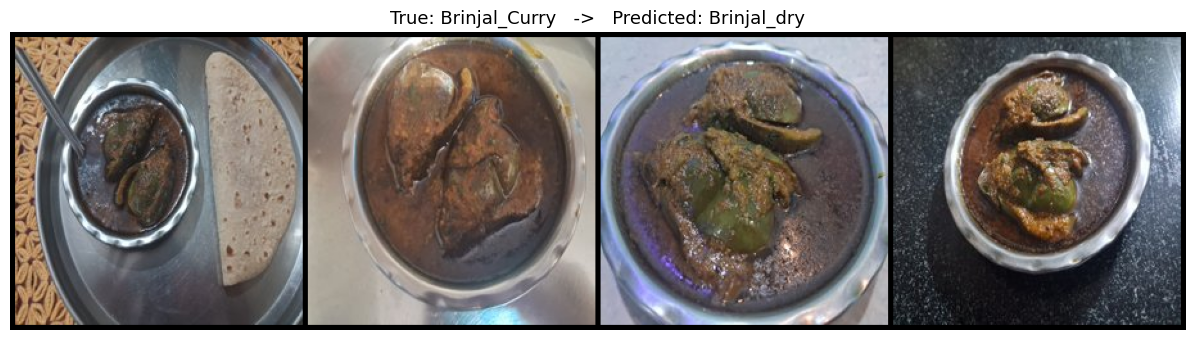

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9b_failure_Dhinkache_laddu_as_Motichoor_Laddu.png


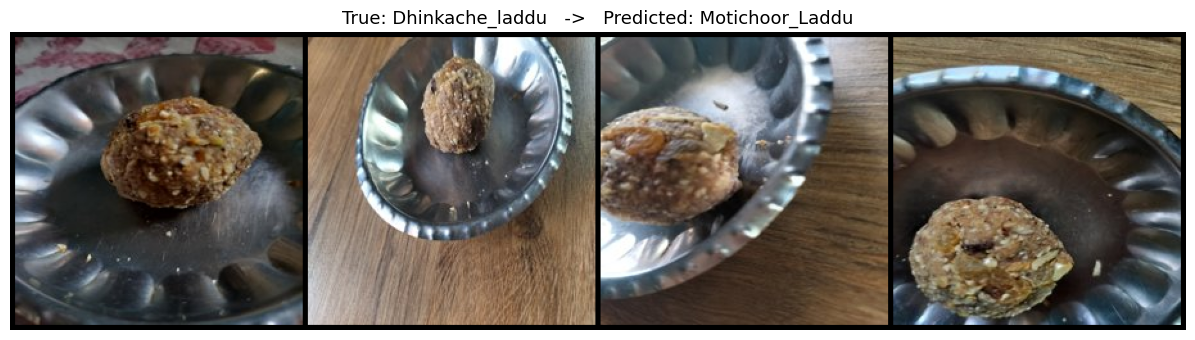

In [ ]:
display_tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
display_test = IndexedDataset(indian_full, test_idx, display_tf)


def show_failures(true_class, pred_class, n=4):
    ti, pi = class_names.index(true_class), class_names.index(pred_class)
    hits = [i for i, (l, p) in enumerate(zip(labels_b32, preds_b32)) if l == ti and p == pi][:n]
    if not hits:
        print(f'  No failures: {true_class} -> {pred_class}')
        return
    grid = make_grid([display_test[i][0] for i in hits], nrow=n, padding=4)
    plt.figure(figsize=(14, 3.5))
    plt.imshow(TF.to_pil_image(grid))
    plt.title(f'True: {true_class}   ->   Predicted: {pred_class}', fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    save_fig(f'fig9b_failure_{true_class}_as_{pred_class}')
    plt.show()


for _, row in confused_pairs.head(5).iterrows():
    show_failures(row['True Class'], row['Predicted Class'])